# Layer 1 Customer Clustering

This notebook creates the Layer 1 customer segmentation for the Merlin UK geographic opportunity prototype.

The purpose of this layer is to cluster MSOAs using public demand-side demographic features only. We exclude Merlin attraction locations, competitor locations, and distance features from the clustering model so the segments describe customer market types rather than current attraction proximity.

## 1. Setup

Import the libraries, define file paths, and set modelling constants. The notebook keeps configuration near the top so later changes are easy to make.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Keep charts readable in the notebook.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Make clustering reproducible. KMeans has random initialisation, so fixing the
# seed ensures the same inputs produce the same segment assignment.
RANDOM_STATE = 42

# We compare several cluster counts, then choose a final value that balances
# model diagnostics with business interpretability.
K_RANGE = range(3, 9)
SELECTED_K = 5

# The notebook lives in notebooks/, so the repository root is one level up when
# running interactively from that folder. This also works when running from repo root.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = DATA_PROCESSED_DIR

# Use the reduced, clustering-ready dataset created in 2_analysis.ipynb.
MSOA_CLUSTER_INPUT_PATH = DATA_PROCESSED_DIR / "msoa_clustering_input.csv"
MSOA_DEMOGRAPHIC_FEATURES_PATH = DATA_PROCESSED_DIR / "msoa_demographic_features.csv"
DATA_DICTIONARY_PATH = DATA_PROCESSED_DIR / "msoa_demographic_features_data_dictionary.csv"

CLUSTERED_OUTPUT_PATH = OUTPUT_DIR / "msoa_layer_1_customer_segments.csv"
SEGMENT_PROFILE_OUTPUT_PATH = OUTPUT_DIR / "msoa_layer_1_segment_profile_summary.csv"

## 2. Load Modelling Data

Load the clustering-ready MSOA dataset created in `2_analysis.ipynb`. Each row should represent one MSOA with the reduced feature set selected for clustering.

In [2]:
# Load the clustering-ready MSOA feature table prepared in notebook 2.
msoa_features = pd.read_csv(MSOA_CLUSTER_INPUT_PATH, dtype={"geo_code": str})

# Raw count fields are not modelling features, but they are useful denominators
# and numerators for downstream opportunity scoring.
RAW_NUMBER_COLUMNS = [
    "children_count_0_14",
    "young_adult_count_15_24",
    "core_family_adult_count_25_44",
    "midlife_adult_count_45_64",
    "older_adult_count_65_plus",
    "total_households",
    "households_with_dependent_children",
    "households_deprived",
    "households_not_deprived",
    "households_no_car_or_van",
    "households_with_car_or_van",
    "residents_social_grade_ab_c1",
]

# Latitude and longitude are not modelling features, but they are useful context
# for mapping and downstream attraction-distance work. Bring them back, along
# with raw count fields, without using them in KMeans.
msoa_context = pd.read_csv(
    MSOA_DEMOGRAPHIC_FEATURES_PATH,
    dtype={"geo_code": str},
    usecols=["geo_code", "latitude", "longitude"] + RAW_NUMBER_COLUMNS,
)
msoa_features = msoa_features.merge(msoa_context, on="geo_code", how="left", validate="one_to_one")
missing_context = msoa_features[["latitude", "longitude"] + RAW_NUMBER_COLUMNS].isna().any(axis=1).sum()
assert missing_context == 0, f"Missing context fields for {missing_context} MSOAs"

# Load the data dictionary for reference. We do not need it for modelling, but it
# is useful to keep nearby when explaining features.
data_dictionary = pd.read_csv(DATA_DICTIONARY_PATH)

# Basic input audit. These checks catch accidental duplicate geographies or empty files early.
input_audit = {
    "rows": len(msoa_features),
    "columns": len(msoa_features.columns),
    "unique_geo_codes": msoa_features["geo_code"].nunique(),
    "duplicate_geo_codes": msoa_features["geo_code"].duplicated().sum(),
    "source_path": str(MSOA_CLUSTER_INPUT_PATH.relative_to(PROJECT_ROOT)),
}

input_audit

{'rows': 7264,
 'columns': 26,
 'unique_geo_codes': 7264,
 'duplicate_geo_codes': 0,
 'source_path': 'data/processed/msoa_clustering_input.csv'}

In [3]:
# Preview the first few rows. We keep this compact because the full table has 7,264 MSOAs.
msoa_features.head()

,geo_code,geo_name,country,total_population,children_share_0_14,young_adult_share_15_24,core_family_adult_share_25_44,midlife_adult_share_45_64,older_adult_share_65_plus,car_access_household_share,...,core_family_adult_count_25_44,midlife_adult_count_45_64,older_adult_count_65_plus,total_households,households_with_dependent_children,households_deprived,households_not_deprived,households_no_car_or_van,households_with_car_or_van,residents_social_grade_ab_c1
0,E02000001,City of London 001,England,8580,0.063636,0.137646,0.406527,0.251632,0.140559,0.227967,...,3488,2159,1206,4916,431,1977,2937,3793,1120,5950
1,E02000002,Barking and Dagenham 001,England,8286,0.262129,0.124065,0.292783,0.208907,0.112117,0.681533,...,2426,1731,929,2871,1350,1916,954,914,1956,2971
2,E02000003,Barking and Dagenham 002,England,11539,0.221856,0.125747,0.316579,0.225669,0.110148,0.705852,...,3653,2604,1271,3931,1660,2281,1649,1156,2774,4756
3,E02000004,Barking and Dagenham 003,England,6638,0.186502,0.122778,0.289093,0.251130,0.150497,0.764400,...,1919,1667,999,2309,835,1295,1014,544,1765,2739
4,E02000005,Barking and Dagenham 004,England,11082,0.264844,0.122270,0.316098,0.217109,0.079679,0.719956,...,3503,2406,883,3627,1804,2086,1544,1016,2612,4628


## 3. Select Clustering Features

For Layer 1, use demand-side customer and household features only.

We do **not** use:

- MSOA latitude or longitude
- Merlin attraction locations
- distance to Merlin attractions
- attraction type features
- competitor data

We also keep `total_population` out of the clustering model. Population size is important for opportunity scoring later, but including it here could make clusters reflect area size rather than customer profile.

In [4]:
# These are the demand-side variables selected for the customer segmentation layer.
# The reduced set removes highly collinear fields identified in 2_analysis.ipynb.
CLUSTERING_FEATURES = [
    "children_share_0_14",
    "young_adult_share_15_24",
    "core_family_adult_share_25_44",
    "midlife_adult_share_45_64",
    "older_adult_share_65_plus",
    "car_access_household_share",
    "population_density_per_sq_km",
    "ab_c1_social_grade_share",
]

# Keep identity and context columns for profiling/export. These do not go into KMeans.
ID_COLUMNS = [
    "geo_code",
    "geo_name",
    "country",
    "latitude",
    "longitude",
    "total_population",
]

# Check that every selected feature exists before continuing.
missing_features = sorted(set(CLUSTERING_FEATURES + ID_COLUMNS + RAW_NUMBER_COLUMNS) - set(msoa_features.columns))
assert not missing_features, f"Missing required columns: {missing_features}"

feature_dictionary = data_dictionary[data_dictionary["column"].isin(CLUSTERING_FEATURES)].copy()
feature_dictionary

,column,description,source_or_derivation
9,children_share_0_14,Share of residents aged 0 to 14.,children_count_0_14 divided by total populatio...
11,young_adult_share_15_24,Share of residents aged 15 to 24.,young_adult_count_15_24 divided by total popul...
13,core_family_adult_share_25_44,Share of residents aged 25 to 44.,core_family_adult_count_25_44 divided by total...
15,midlife_adult_share_45_64,Share of residents aged 45 to 64.,midlife_adult_count_45_64 divided by total pop...
17,older_adult_share_65_plus,Share of residents aged 65 and over.,older_adult_count_65_plus divided by total pop...
27,car_access_household_share,Share of households with at least one car or v...,households_with_car_or_van divided by the car ...
28,population_density_per_sq_km,Population density measured as residents per s...,Census 2021 population density table from Nomis
30,ab_c1_social_grade_share,Share of residents in approximated social grad...,residents_social_grade_ab_c1 divided by the so...


In [5]:
# Inspect missingness and basic ranges before preprocessing.
# A good clustering workflow checks inputs before scaling or modelling.
feature_quality = (
    msoa_features[CLUSTERING_FEATURES]
    .agg(["count", "min", "mean", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)
feature_quality["missing_rows"] = len(msoa_features) - feature_quality["count"]
feature_quality

,feature,count,min,mean,max,missing_rows
0,children_share_0_14,7264.0,0.014016,0.172368,0.368466,0.0
1,young_adult_share_15_24,7264.0,0.048405,0.114822,0.782135,0.0
2,core_family_adult_share_25_44,7264.0,0.093444,0.261434,0.618401,0.0
3,midlife_adult_share_45_64,7264.0,0.040125,0.260895,0.353829,0.0
4,older_adult_share_65_plus,7264.0,0.008499,0.190481,0.528791,0.0
5,car_access_household_share,7264.0,0.179562,0.770087,0.972030,0.0
6,population_density_per_sq_km,7264.0,5.400000,3421.895237,23873.400000,0.0
7,ab_c1_social_grade_share,7264.0,0.179352,0.565470,0.922123,0.0


## 4. Preprocess Features

KMeans is distance-based, so preprocessing matters.

Steps:

1. Copy only the selected clustering features.
2. Log-transform population density because density is highly skewed.
3. Impute any missing values with the median.
4. Standardise all features so each variable contributes on a comparable scale.

In [6]:
# Copy the modelling features so the original DataFrame remains untouched.
X_raw = msoa_features[CLUSTERING_FEATURES].copy()

# Population density is often very skewed: a few dense urban MSOAs can dominate
# distance-based models. log1p keeps zero-safe values and reduces that skew.
X_model = X_raw.copy()
X_model["log_population_density_per_sq_km"] = np.log1p(X_model["population_density_per_sq_km"])
X_model = X_model.drop(columns=["population_density_per_sq_km"])

MODEL_FEATURES = X_model.columns.tolist()

# Median imputation is robust and simple. The current dataset has no missing
# values in these fields, but keeping the imputer makes the notebook safer.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_model)

# Standardisation is essential before KMeans because the model uses Euclidean distance.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

preprocessing_summary = pd.DataFrame(
    {
        "model_feature": MODEL_FEATURES,
        "imputation_value": imputer.statistics_,
        "scaled_mean_after_transform": X_scaled.mean(axis=0).round(6),
        "scaled_std_after_transform": X_scaled.std(axis=0).round(6),
    }
)

preprocessing_summary

,model_feature,imputation_value,scaled_mean_after_transform,scaled_std_after_transform
0,children_share_0_14,0.170559,-0.0,1.0
1,young_adult_share_15_24,0.102599,-0.0,1.0
2,core_family_adult_share_25_44,0.254522,0.0,1.0
3,midlife_adult_share_45_64,0.266225,0.0,1.0
4,older_adult_share_65_plus,0.190479,-0.0,1.0
5,car_access_household_share,0.805492,0.0,1.0
6,ab_c1_social_grade_share,0.568521,0.0,1.0
7,log_population_density_per_sq_km,7.852050,0.0,1.0


## 5. Compare Candidate Cluster Counts

We compare `k = 3` to `k = 8` using inertia, silhouette score, and cluster sizes.

Silhouette score is useful, but the final choice should also consider whether the segments are large enough and commercially interpretable. For this prototype, `k = 5` is selected because it gives a practical balance: enough nuance to separate family, urban, young-adult, mainstream, and older/rural markets without creating too many tiny segments.

In [7]:
cluster_diagnostics = []

for k in K_RANGE:
    # n_init=50 makes KMeans more stable by trying multiple centroid starts.
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    labels = model.fit_predict(X_scaled)
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    cluster_diagnostics.append(
        {
            "k": k,
            # sum of squared distances from each data point to the centroid of the cluster it belongs to
            "inertia": model.inertia_,
            # a higher score means points are close to their own cluster and far from other clusters
            "silhouette_score": silhouette_score(X_scaled, labels),
            "min_cluster_size": cluster_sizes.min(),
            "max_cluster_size": cluster_sizes.max(),
        }
    )

cluster_diagnostics = pd.DataFrame(cluster_diagnostics)
cluster_diagnostics

,k,inertia,silhouette_score,min_cluster_size,max_cluster_size
0,3,30005.976269,0.320866,592,3610
1,4,25370.782194,0.251660,551,2970
2,5,21014.527868,0.266415,139,2950
3,6,19041.761379,0.223804,136,2061
4,7,17526.226859,0.227187,136,1646
5,8,16415.658962,0.225822,139,1435


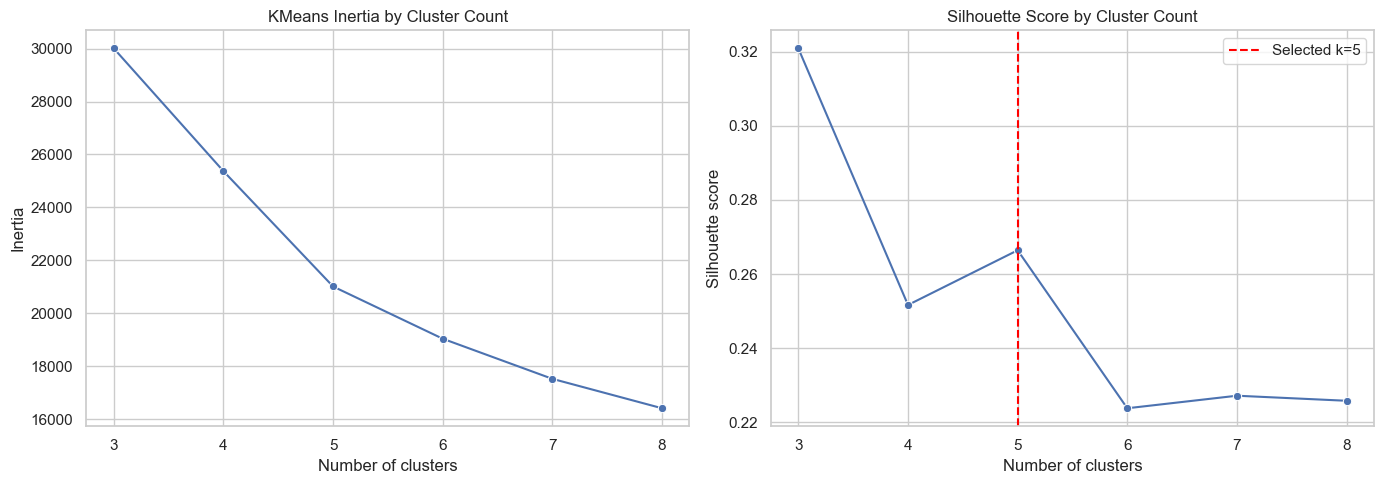

In [8]:
# Plot diagnostics side by side. Inertia usually decreases as k rises, while
# silhouette helps assess separation. We use these as guidance, not as an automatic rule.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=cluster_diagnostics, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("KMeans Inertia by Cluster Count")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=cluster_diagnostics, x="k", y="silhouette_score", marker="o", ax=axes[1])
axes[1].axvline(SELECTED_K, color="red", linestyle="--", label=f"Selected k={SELECTED_K}")
axes[1].set_title("Silhouette Score by Cluster Count")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Fit Final Clustering Model

Fit the final KMeans model with the selected cluster count and attach the segment ID back to each MSOA.

In [9]:
final_kmeans = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=50)
cluster_labels = final_kmeans.fit_predict(X_scaled)

clustered_msoa = msoa_features.copy()
clustered_msoa["segment_id"] = cluster_labels

cluster_size_summary = (
    clustered_msoa["segment_id"]
    .value_counts()
    .sort_index()
    .rename_axis("segment_id")
    .reset_index(name="msoa_count")
)
cluster_size_summary["msoa_share"] = cluster_size_summary["msoa_count"] / len(clustered_msoa)
cluster_size_summary

,segment_id,msoa_count,msoa_share
0,0,599,0.082461
1,1,1883,0.259224
2,2,1693,0.233067
3,3,139,0.019135
4,4,2950,0.406112


## 7. Profile Segments

Profiling translates the cluster assignments into business meaning. We compare segment averages against the overall MSOA average and then assign simple human-readable labels.

### 7.1 Mean variables per segment

In [10]:
# Profile both clustering features and useful context fields that were not used
# by the model, such as total population.
PROFILE_COLUMNS = CLUSTERING_FEATURES + ["total_population"]

overall_profile = msoa_features[PROFILE_COLUMNS].mean()

segment_profile = (
    clustered_msoa.groupby("segment_id")
    .agg(
        msoa_count=("geo_code", "count"),
        total_population_sum=("total_population", "sum"),
        **{f"{column}_mean": (column, "mean") for column in PROFILE_COLUMNS}
    )
    .reset_index()
)
segment_profile["msoa_share"] = segment_profile["msoa_count"] / len(clustered_msoa)
segment_profile["population_share"] = segment_profile["total_population_sum"] / clustered_msoa["total_population"].sum()

segment_profile.round(4)

,segment_id,msoa_count,total_population_sum,children_share_0_14_mean,young_adult_share_15_24_mean,core_family_adult_share_25_44_mean,midlife_adult_share_45_64_mean,older_adult_share_65_plus_mean,car_access_household_share_mean,population_density_per_sq_km_mean,ab_c1_social_grade_share_mean,total_population_mean,msoa_share,population_share
0,0,599,5215418,0.1499,0.1416,0.3955,0.2146,0.0984,0.4839,10586.7457,0.6400,8706.8748,0.0825,0.0875
1,1,1883,14498628,0.1472,0.0909,0.1968,0.2940,0.2711,0.8877,516.0788,0.6325,7699.7493,0.2592,0.2433
2,2,1693,14664084,0.2137,0.1262,0.2969,0.2350,0.1282,0.6762,5032.8947,0.4077,8661.5972,0.2331,0.2461
3,3,139,1357844,0.0898,0.4404,0.2484,0.1353,0.0861,0.5978,6520.2029,0.6953,9768.6619,0.0191,0.0228
4,4,2950,23861389,0.1732,0.1028,0.2557,0.2699,0.1984,0.8151,2751.3257,0.5919,8088.6064,0.4061,0.4004


### 7.2 Mean variables z-score per segment

In [11]:
# Create z-score style profile differences for interpretation. Positive values
# mean the segment is above the national MSOA average for that feature.
profile_feature_means = clustered_msoa.groupby("segment_id")[PROFILE_COLUMNS].mean()
profile_feature_std = msoa_features[PROFILE_COLUMNS].std()
segment_profile_indexed = segment_profile.set_index("segment_id")

profile_difference = (profile_feature_means - overall_profile) / profile_feature_std
profile_difference = profile_difference.round(2)
profile_difference

,children_share_0_14,young_adult_share_15_24,core_family_adult_share_25_44,midlife_adult_share_45_64,older_adult_share_65_plus,car_access_household_share,population_density_per_sq_km,ab_c1_social_grade_share,total_population
segment_id,,,,,,,,,
0,-0.63,0.48,2.09,-1.22,-1.30,-1.99,1.98,0.53,0.28
1,-0.71,-0.43,-1.01,0.87,1.14,0.82,-0.80,0.48,-0.28
2,1.16,0.21,0.55,-0.68,-0.88,-0.65,0.44,-1.13,0.25
3,-2.31,5.85,-0.20,-3.31,-1.47,-1.20,0.85,0.93,0.86
4,0.02,-0.22,-0.09,0.24,0.11,0.31,-0.19,0.19,-0.06


### 7.3 Naming segments

Segment names are descriptive shorthand for the cluster profiles. They should only use evidence available in the clustering features, so we avoid geographic claims such as coastal unless a coastal indicator is added later.

The naming rules are applied in priority order:

- **Student & Young Adult Urban Markets**: very high young-adult share. This captures university/student-heavy markets before other urban rules are considered.
- **Dense Urban Professional Markets**: very high population density, low car access, and above-average affluence. The low car-access condition helps distinguish dense urban markets from suburban or rural car-dependent areas.
- **Affluent Family Suburban Markets**: high child share, high car access, above-average affluence, and moderate density. Car access alone is not enough to call a segment suburban because rural areas can be even more car-dependent.
- **Older Rural & Low-Density Markets**: high older-adult share and low population density. This replaces the previous coastal wording because density can support a rural or low-density interpretation, but it cannot prove coastal geography.
- **Mainstream Affluent Suburban Markets**: high car access, above-average affluence, and moderate density, without the stronger family signal above.
- **Balanced Regional Family Markets**: the remaining segment, with family-oriented characteristics but less affluence and car access than the suburban segments.

In [12]:
def assign_segment_label(row):
    """Assign a plain-English segment label from the cluster profile.

    These rules are simple. They are based on the average profile
    of each cluster, not on individual MSOAs. After reviewing results, labels can
    be refined for the final presentation.
    """
    if row["young_adult_share_15_24_mean"] >= 0.25:
        return "Student & Young Adult Urban Markets"

    if (
        row["population_density_per_sq_km_mean"] >= 8000
        and row["car_access_household_share_mean"] <= 0.60
        and row["ab_c1_social_grade_share_mean"] >= 0.55
    ):
        return "Dense Urban Professional Markets"

    if (
        row["children_share_0_14_mean"] >= 0.20
        and 1200 < row["population_density_per_sq_km_mean"] < 5000
        and row["car_access_household_share_mean"] >= 0.75
        and row["ab_c1_social_grade_share_mean"] >= 0.55
    ):
        return "Affluent Family Suburban Markets"

    if (
        row["older_adult_share_65_plus_mean"] >= 0.24
        and row["population_density_per_sq_km_mean"] <= 1200
    ):
        return "Older Rural & Low-Density Markets"

    if (
        1200 < row["population_density_per_sq_km_mean"] < 5000
        and row["car_access_household_share_mean"] >= 0.78
        and row["ab_c1_social_grade_share_mean"] >= 0.55
    ):
        return "Mainstream Affluent Suburban Markets"

    return "Balanced Regional Family Markets"


segment_labels = segment_profile.copy()
segment_labels["segment_label"] = segment_labels.apply(assign_segment_label, axis=1)
segment_labels = segment_labels[["segment_id", "segment_label"]]

clustered_msoa = clustered_msoa.drop(columns=["segment_label"], errors="ignore")
segment_profile = segment_profile.drop(columns=["segment_label"], errors="ignore")

clustered_msoa = clustered_msoa.merge(segment_labels, on="segment_id", how="left")
segment_profile = segment_profile.merge(segment_labels, on="segment_id", how="left")

segment_profile[["segment_id", "segment_label", "msoa_count", "msoa_share", "population_share"]].sort_values("segment_id")

,segment_id,segment_label,msoa_count,msoa_share,population_share
0,0,Dense Urban Professional Markets,599,0.082461,0.087511
1,1,Older Rural & Low-Density Markets,1883,0.259224,0.243276
2,2,Balanced Regional Family Markets,1693,0.233067,0.246053
3,3,Student & Young Adult Urban Markets,139,0.019135,0.022784
4,4,Mainstream Affluent Suburban Markets,2950,0.406112,0.400377


In [13]:
# Show a compact profile table for stakeholder interpretation.
profile_display_columns = [
    "segment_id",
    "segment_label",
    "msoa_count",
    "msoa_share",
    "population_share",
    "children_share_0_14_mean",
    "young_adult_share_15_24_mean",
    "car_access_household_share_mean",
    "population_density_per_sq_km_mean",
    "ab_c1_social_grade_share_mean",
]

segment_profile_summary = segment_profile[profile_display_columns].copy()
segment_profile_summary.round(4)

,segment_id,segment_label,msoa_count,msoa_share,population_share,children_share_0_14_mean,young_adult_share_15_24_mean,car_access_household_share_mean,population_density_per_sq_km_mean,ab_c1_social_grade_share_mean
0,0,Dense Urban Professional Markets,599,0.0825,0.0875,0.1499,0.1416,0.4839,10586.7457,0.6400
1,1,Older Rural & Low-Density Markets,1883,0.2592,0.2433,0.1472,0.0909,0.8877,516.0788,0.6325
2,2,Balanced Regional Family Markets,1693,0.2331,0.2461,0.2137,0.1262,0.6762,5032.8947,0.4077
3,3,Student & Young Adult Urban Markets,139,0.0191,0.0228,0.0898,0.4404,0.5978,6520.2029,0.6953
4,4,Mainstream Affluent Suburban Markets,2950,0.4061,0.4004,0.1732,0.1028,0.8151,2751.3257,0.5919


## 8. Visualise Segments

### 8.1 PCA scatterplot

Use PCA only for visual inspection. PCA is not the clustering model; it reduces the scaled feature matrix to two dimensions so we can see whether the segments have some separation.

PCA chart explains 70.6% of scaled feature variance across the first two components.


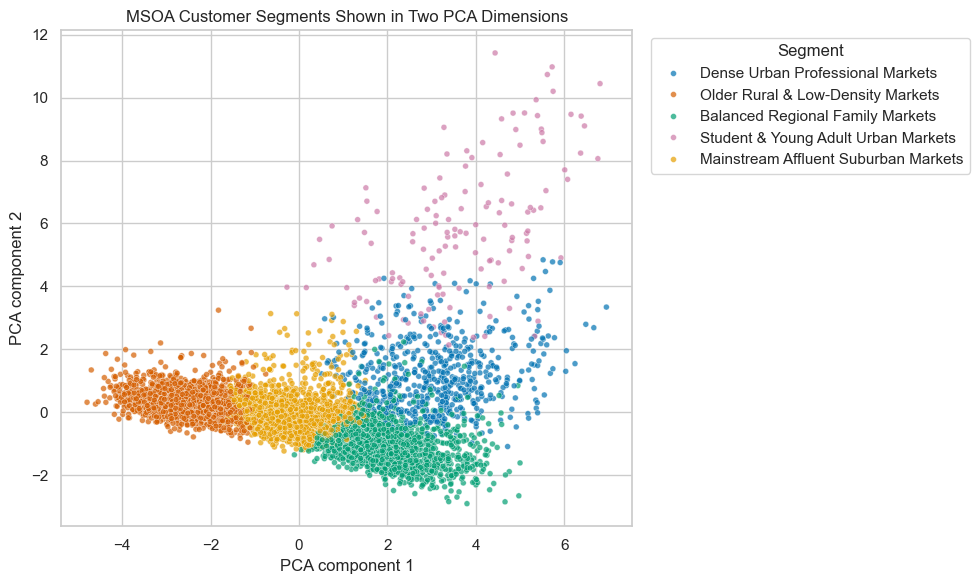

In [14]:
# Reduce the scaled feature matrix to two dimensions for a simple diagnostic chart.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(X_scaled)

pca_plot_data = clustered_msoa[["geo_code", "geo_name", "segment_id", "segment_label"]].copy()
pca_plot_data["pca_1"] = pca_coordinates[:, 0]
pca_plot_data["pca_2"] = pca_coordinates[:, 1]

explained_variance = pca.explained_variance_ratio_.sum()
print(f"PCA chart explains {explained_variance:.1%} of scaled feature variance across the first two components.")

# Use an explicit colour-blind-safe categorical palette so segment colours remain
# readable and stable across notebook reruns.
segment_hue_order = segment_profile.sort_values("segment_id")["segment_label"].tolist()
segment_palette = dict(
    zip(
        segment_hue_order,
        ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00"],
    )
)

sns.scatterplot(
    data=pca_plot_data,
    x="pca_1",
    y="pca_2",
    hue="segment_label",
    hue_order=segment_hue_order,
    palette=segment_palette,
    s=18,
    alpha=0.7,
)
plt.title("MSOA Customer Segments Shown in Two PCA Dimensions")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**PCA scatterplot insights**

The first two PCA components explain about 71% of the scaled feature variance, so the chart is useful as a diagnostic view of the segment structure. It should still be read as a compressed two-dimensional projection rather than as the clustering model itself.

- **Older Rural & Low-Density Markets** (orange) sit on the opposite side of PCA component 1 from the dense urban and family-oriented segments. This is consistent with their low density, older age profile, and high car access.
- **Dense Urban Professional Markets** (blue) and **Student & Young Adult Urban Markets** (pink) occupy the higher-density side of the plot. The student segment is visually distinct on PCA component 2, reflecting its unusually high young-adult share.
- **Mainstream Affluent Suburban Markets** (yellow) are closer to the middle of the PCA space, which fits their role as a large, moderate-density, high-car-access segment rather than an extreme urban or rural cluster.
- **Balanced Regional Family Markets** (green) overlap more with neighbouring segments in this two-dimensional view. It suggests its identity is more about a combination of family share, lower affluence, and regional density than one single extreme feature.
- The visible separation supports the five-segment solution at a high level, but overlap between points is expected because KMeans used the full scaled feature set, not just these two PCA axes.

### 8.2 Z-score per segment heatmap

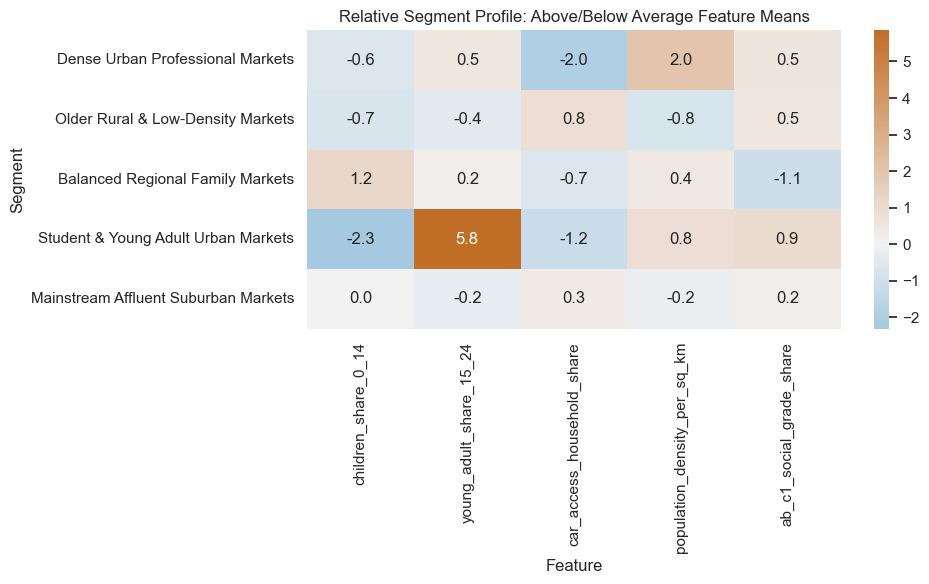

In [15]:
# Visualise the existing z-score profile differences from section 7.2.
heatmap_features = [
    "children_share_0_14",
    "young_adult_share_15_24",
    "car_access_household_share",
    "population_density_per_sq_km",
    "ab_c1_social_grade_share",
]

heatmap_profile_scaled = (
    profile_difference[heatmap_features]
    .join(segment_profile.set_index("segment_id")["segment_label"])
    .set_index("segment_label")
)

# Use a blue-to-orange diverging scale: blue means below average, orange means above average.
heatmap_cmap = sns.diverging_palette(240, 35, s=90, l=55, as_cmap=True)
sns.heatmap(heatmap_profile_scaled, cmap=heatmap_cmap, center=0, annot=True, fmt=".1f")
plt.title("Relative Segment Profile: Above/Below Average Feature Means")
plt.xlabel("Feature")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

**Merlin target segment priorities**

This prioritisation is based on the heatmap and segment profile, not on current attraction proximity. It treats Merlin demand as strongest where there is a good mix of family relevance, ability to spend, mobility, and enough population scale.

1. **Mainstream Affluent Suburban Markets**: highest priority. This is the largest segment by both MSOA share and population share, with above-average car access and above-average AB/C1 share. It should be a strong core audience for Merlin because households are relatively mobile, affluent, and numerous, with enough family presence to support attraction visits.
2. **Balanced Regional Family Markets**: second priority. This segment has the strongest child share and good population scale, so it is likely relevant for family-led demand. The lower AB/C1 share and lower car access than the suburban segment suggest a more value-sensitive audience, so offers, bundles, school-holiday campaigns, and regional partnerships may matter more.
3. **Dense Urban Professional Markets**: selective priority. These areas are affluent and dense, but lower car access and only moderate child share mean they may work better for city-accessible attractions, short breaks, premium experiences, or public-transport-led campaigns than for car-dependent family day trips.
4. **Older Rural & Low-Density Markets**: lower priority for broad Merlin targeting. The segment is affluent and highly car-accessible, but it has an older age profile, low child share, low young-adult share, and low density. It may still be useful for specific offers such as multi-generational visits, short breaks, or destination attractions, but it is unlikely to be the main family-growth audience.
5. **Student & Young Adult Urban Markets**: lowest priority for core family targeting. The young-adult share is very high and affluence is strong, but the segment is small and has the lowest child share. It may be relevant for adult leisure, city attractions, events, and off-peak promotions, but it is not likely to be a primary target for family-oriented Merlin demand.

Overall, Merlin should prioritise **Mainstream Affluent Suburban Markets** for broad acquisition, use **Balanced Regional Family Markets** as a large value-led family opportunity, and treat the other segments as more selective or product-specific audiences.

## 9. Export Layer 1 Outputs

Export the clustered MSOA table and segment profile summary for the next modelling layer. The next layer can add opportunity scoring and Merlin attraction alignment.

In [16]:
# Keep the export focused: identifiers, segment assignment, and the demographic
# features needed for profiling/scoring.
EXPORT_COLUMNS = [
    "geo_code",
    "geo_name",
    "country",
    "latitude",
    "longitude",
    "segment_id",
    "segment_label",
    "total_population",
] + RAW_NUMBER_COLUMNS + CLUSTERING_FEATURES

clustered_export = clustered_msoa[EXPORT_COLUMNS].copy()

clustered_export.to_csv(CLUSTERED_OUTPUT_PATH, index=False)
segment_profile_summary.to_csv(SEGMENT_PROFILE_OUTPUT_PATH, index=False)

export_audit = {
    "clustered_rows": len(clustered_export),
    "clustered_columns": len(clustered_export.columns),
    "clustered_output_path": str(CLUSTERED_OUTPUT_PATH.relative_to(PROJECT_ROOT)),
    "segment_profile_rows": len(segment_profile_summary),
    "segment_profile_output_path": str(SEGMENT_PROFILE_OUTPUT_PATH.relative_to(PROJECT_ROOT)),
}

export_audit

{'clustered_rows': 7264,
 'clustered_columns': 28,
 'clustered_output_path': 'data/processed/msoa_layer_1_customer_segments.csv',
 'segment_profile_rows': 5,
 'segment_profile_output_path': 'data/processed/msoa_layer_1_segment_profile_summary.csv'}

In [17]:
# Preview the final clustered output.
clustered_export.head()

,geo_code,geo_name,country,latitude,longitude,segment_id,segment_label,total_population,children_count_0_14,young_adult_count_15_24,...,households_with_car_or_van,residents_social_grade_ab_c1,children_share_0_14,young_adult_share_15_24,core_family_adult_share_25_44,midlife_adult_share_45_64,older_adult_share_65_plus,car_access_household_share,population_density_per_sq_km,ab_c1_social_grade_share
0,E02000001,City of London 001,England,51.51562,-0.093490,0,Dense Urban Professional Markets,8580,546,1181,...,1120,5950,0.063636,0.137646,0.406527,0.251632,0.140559,0.227967,2975.0,0.840514
1,E02000002,Barking and Dagenham 001,England,51.58652,0.138756,2,Balanced Regional Family Markets,8286,2172,1028,...,1956,2971,0.262129,0.124065,0.292783,0.208907,0.112117,0.681533,3831.0,0.410756
2,E02000003,Barking and Dagenham 002,England,51.57606,0.138149,2,Balanced Regional Family Markets,11539,2560,1451,...,2774,4756,0.221856,0.125747,0.316579,0.225669,0.110148,0.705852,5389.7,0.473847
3,E02000004,Barking and Dagenham 003,England,51.55639,0.176828,4,Mainstream Affluent Suburban Markets,6638,1238,815,...,1765,2739,0.186502,0.122778,0.289093,0.251130,0.150497,0.764400,2663.6,0.508069
4,E02000005,Barking and Dagenham 004,England,51.56069,0.144267,2,Balanced Regional Family Markets,11082,2935,1355,...,2612,4628,0.264844,0.122270,0.316098,0.217109,0.079679,0.719956,9327.5,0.461278


## 10. Layer 1 Notes and Next Steps

Layer 1 is now complete: each MSOA has a demand-side customer segment.

Next steps for Layer 2:

- Build transparent opportunity scores using market size, family potential, affluence, mobility, and attraction fit.
- Use Merlin attraction data for recommended attraction focus and activation logic.
- Optionally add distance to Merlin attractions as an opportunity scoring feature, not as a clustering feature.
- Keep competitor analysis out of this prototype unless time allows in a later iteration.